In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import RocCurveDisplay

pd.set_option('display.max_columns', None)

## Load Dataset

In [8]:
df = pd.read_csv("Dataset/diabetes_binary_health_indicators_BRFSS2015.csv")
df.columns = df.columns.str.lower()
df.head()

,diabetes_binary,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,veggies,hvyalcoholconsump,anyhealthcare,nodocbccost,genhlth,menthlth,physhlth,diffwalk,sex,age,education,income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Train / Validation / Test Split

In [10]:
def split_features_target(df):
    X = df.drop("diabetes_binary", axis=1)
    y = df["diabetes_binary"]
    return X, y

X, y = split_features_target(df)


In [11]:
def train_test_split_data(X, y, test_size=0.2, random_state=42):
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

X_train, X_test, y_train, y_test = train_test_split_data(X, y)

# Scaling and Modelling

In [12]:
def scale_data(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, scaler

X_train_scaled, X_test_scaled, scaler = scale_data(X_train, X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Isolation Forest": IsolationForest(contamination=0.05, random_state=42)
}

def fit_and_score(models, X_train, X_test, y_train, y_test):

    np.random.seed(42)
    model_scores = {}

    for name, model in models.items():

        # If it is a anomaly detection model
        if name == "Isolation Forest":
            model.fit(X_train)

            y_pred = model.predict(X_test)
            y_pred = [1 if x == -1 else 0 for x in y_pred]
            model_scores[name] = {
                "accuracy": round(accuracy_score(y_test, y_pred),2),
                "precision": round(precision_score(y_test, y_pred),2),
                "recall": round(recall_score(y_test, y_pred),2),
                "f1": round(f1_score(y_test, y_pred),2)
            }

        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            model_scores[name] = {
                "accuracy": round(accuracy_score(y_test, y_pred),2),
                "precision": round(precision_score(y_test, y_pred),2),
                "recall": round(recall_score(y_test, y_pred),2),
                "f1": round(f1_score(y_test, y_pred),2)
            }

    return model_scores

model_scores = fit_and_score(models=models,
                             X_train=X_train_scaled,
                             X_test=X_test_scaled,
                             y_train=y_train,
                             y_test=y_test)

model_scores

{'Logistic Regression': {'accuracy': 0.86,
  'precision': 0.52,
  'recall': 0.16,
  'f1': 0.24},
 'Random Forest': {'accuracy': 0.86,
  'precision': 0.49,
  'recall': 0.18,
  'f1': 0.26},
 'Naive Bayes': {'accuracy': 0.77,
  'precision': 0.32,
  'recall': 0.56,
  'f1': 0.41},
 'Decision Tree': {'accuracy': 0.8,
  'precision': 0.3,
  'recall': 0.33,
  'f1': 0.31},
 'Isolation Forest': {'accuracy': 0.84,
  'precision': 0.31,
  'recall': 0.11,
  'f1': 0.16}}

In [13]:
df_model_scores = pd.DataFrame(model_scores).T
print(df_model_scores.sort_values("f1", ascending=False))

                     accuracy  precision  recall    f1
Naive Bayes              0.77       0.32    0.56  0.41
Decision Tree            0.80       0.30    0.33  0.31
Random Forest            0.86       0.49    0.18  0.26
Logistic Regression      0.86       0.52    0.16  0.24
Isolation Forest         0.84       0.31    0.11  0.16


Hyperparameter tuning with RandomizedSearchCV (CV= Cross Validated)


In [14]:
# hyperparamter grids
param_grids = {

    "Logistic Regression": {
        "C": np.logspace(-4, 4, 20),
        "solver": ['liblinear', 'lbfgs']
    },

    "Random Forest": {
        "n_estimators": np.arange(50, 200, 25),
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": np.arange(2, 10, 2),
        "min_samples_leaf": np.arange(1, 5, 1),
        "max_features": ['sqrt', 'log2']
    },

    "Naive Bayes": {
        "var_smoothing": np.logspace(0, -9, 100)
    },

    "Decision Tree": {
        "max_depth": [None, 5, 10, 20, 30],
        "min_samples_split": np.arange(2, 10, 2),
        "min_samples_leaf": np.arange(1, 5, 1),
        "criterion": ['gini', 'entropy']
    },

    "Isolation Forest": {
        "n_estimators": np.arange(50, 200, 25),
        "max_samples": ['auto', 0.5, 0.75, 1.0],
        "contamination": [0.01, 0.05, 0.1],
        "max_features": np.arange(1, X_train.shape[1] + 1),
        "bootstrap": [True, False]
    }
}

## Tuning the models
def tune_all_models(models, param_grids, X_train, y_train, X_test, y_test):
    results = []

    for name, model in models.items():
        print(f"\n Tuning {name}")

        np.random.seed(42)

        if name == "Isolation Forest":
            rs = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grids[name],
                n_iter=20,
                cv=3,
                verbose=1,
                n_jobs=-1,
                scoring="f1"
            )

            rs.fit(X_train)  

            best_model = rs.best_estimator_
            y_pred = best_model.predict(X_test)
            y_pred = np.where(y_pred == -1, 1, 0)
            test_score = f1_score(y_test, y_pred, zero_division=0
            results.append({
                "Model": name,
                "Best Params": rs.best_params_,
                "Score": np.nan
            })

            print(f" Best Params: {rs.best_params_}")
            print(f"F1 Score: {test_score:.2f}")
            print("No test score (unsupervised model)")
            continue

        # Supervised models
        rs = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grids[name],
            n_iter=20,
            cv=5,
            verbose=1,
            n_jobs=1
        )

        rs.fit(X_train, y_train)

        best_params = rs.best_params_
        test_score = rs.score(X_test, y_test)

        results.append({
            "Model": name,
            "Best Params": best_params,
            "Score": np.nan
        })

        print(f"Best Params: {best_params}")
        print(f"Test Score: {test_score:.2f}")

    return pd.DataFrame(results)

results_df = tune_all_models(
                             models,
                             param_grids,
                             X_train_scaled,
                             y_train,
                             X_test_scaled,
                             y_test
                            )

# Sorting them by score
results_df_sorted = results_df.sort_values(by="Score", ascending=False, na_position='last')

print("\n Final Results:")
print(results_df_sorted)


 Tuning Logistic Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'solver': 'liblinear', 'C': 0.0006951927961775605}
Test Score: 0.86

 Tuning Random Forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'n_estimators': 150, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}
Test Score: 0.87

 Tuning Naive Bayes
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'var_smoothing': 1.0}
Test Score: 0.83

 Tuning Decision Tree
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'min_samples_split': 4, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'gini'}
Test Score: 0.86

 Tuning Isolation Forest
Fitting 3 folds for each of 20 candidates, totalling 60 fits
 Best Params: {'n_estimators': 100, 'max_samples': 1.0, 'max_features': 15, 'contamination': 0.05, 'bootstrap': True}
F1 Score: 0.14
No test score (unsupervised model)

 Final Res

Hyperparameter Tuning with GridSearchCV

In [15]:
# trying different hyperparameter for our RandomForestClassifier model
rf_grid = {
        "n_estimators": np.arange(50, 200, 25),
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": np.arange(2, 10, 2),
        "min_samples_leaf": np.arange(1, 5, 1),
        "max_features": ['sqrt', 'log2']
}

np.random.seed(42)

gs_rf = GridSearchCV(RandomForestClassifier(),
                           param_grid=rf_grid,
                           cv=10,
                           verbose=True,
                           n_jobs=4)
gs_rf.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 768 candidates, totalling 7680 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': array([1, 2, 3, 4]), 'min_samples_split': array([2, 4, 6, 8]), ...}"
,scoring,None
,n_jobs,4
,refit,True
,cv,10
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [16]:
#Finding the best hyperparameter for RandomForestClassifier
gs_rf.best_params_

{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 8,
 'n_estimators': 100}

In [17]:
gs_rf.score(X_test_scaled,y_test)

0.8651647745190791

In [21]:
## ideal hyperparameter
ideal_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    max_features="sqrt",
    min_samples_leaf=4,
    min_samples_split=8,
    n_jobs=-1,
    random_state=42
)

In [23]:
## Fiting the model again
ideal_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,8
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
ideal_model.score(X_test_scaled, y_test)

0.8651647745190791

Evaluating our tuned machine learning classifier, beyond accuracy
To make comparisons and evaluate our trained model, first we need to make predictions.

In [25]:
# Making predictions with tuned models
y_predicts = gs_rf.predict(X_test_scaled)

In [28]:
# plotting roc curve

def plot_roc_auc(model, X_test, y_test, figsize=(6, 5)):
    plt.figure(figsize=figsize)
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title("ROC Curve")
    plt.grid(True)
    plt.show()

    y_probs = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_probs)
    print(f"AUC Score: {auc_score:.4f}")

<Figure size 600x500 with 0 Axes>

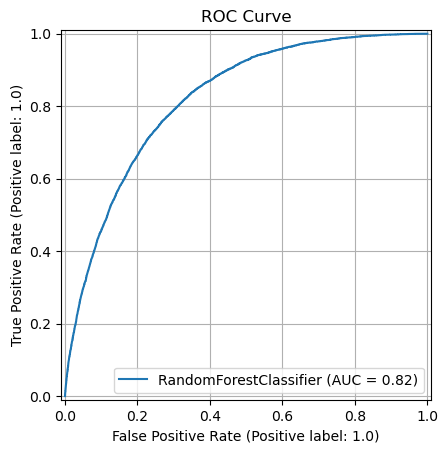

AUC Score: 0.8211


In [29]:
plot_roc_auc(ideal_model, X_test_scaled, y_test)

In [30]:
#Confusion Matrix
print(confusion_matrix(y_test, y_predicts))

[[42930   737]
 [ 6104   965]]


In [31]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_predicts):
  """
  Plot a confusion matrix using Seaborn's heatmap()
  """
  fig, ax = plt.subplots(figsize=(3,3))
  ax = sns.heatmap(confusion_matrix(y_test,y_predicts),
                  annot=True,
                   cbar=False)
  plt.xlabel("True label")
  plt.ylabel("Predicted label")

plot_conf_mat(y_test, y_predicts)

In [32]:
print(classification_report(y_test, y_predicts))

              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43667
         1.0       0.57      0.14      0.22      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.56      0.57     50736
weighted avg       0.83      0.87      0.83     50736



Calculating the accuracy, precision, recall, and f1-score of our model using cross-validation[cross_val_score()]


In [33]:
gs_rf.best_params_

{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 8,
 'n_estimators': 100}

In [58]:
clf = RandomForestClassifier(max_depth=20,
                             max_features="sqrt",
                             min_samples_leaf=4,
                             min_samples_split=8,
                             n_estimators=100)

In [69]:
## Cross-validated accuracy

cv_accuracy = cross_val_score(clf,
                         X,
                         y,
                         cv=10,
                         scoring="accuracy")
cv_accuracy

array([0.86636708, 0.86538158, 0.86699779, 0.86447493, 0.86546042,
       0.86427783, 0.86735257, 0.86593346, 0.86557868, 0.86565752])

In [70]:
cv_accuracy = np.mean(cv_accuracy)
cv_accuracy

0.8657481866918953

In [71]:
## Cross-validated precision

cv_precision = cross_val_score(clf,
                               X,
                               y,
                               cv=10,
                               scoring="precision")
cv_precision = np.mean(cv_precision)
cv_precision

0.5835310485243503

In [72]:
## Cross-validated recall

cv_recall = cross_val_score(clf,
                               X,
                               y,
                               cv=10,
                               scoring="recall")
cv_recall = np.mean(cv_recall)
cv_recall

0.1344991350942031

In [66]:
## Cross-validated f1-score

cv_f1 = cross_val_score(clf,
                               X,
                               y,
                               cv=10,
                               scoring="f1")
cv_f1 = np.mean(cv_f1)
cv_f1

0.2199456133367169

In [67]:
# Visualizing the cross-validated metrics

cv_metrics = pd.DataFrame({"Accuracy":cv_accuracy,
                           "Precision":cv_precision,
                           "Recall":cv_recall,
                           "F1":cv_f1},
                          index=[0])
cv_metrics.T.plot.bar(title="Cross-validated classification metrics",
                      legend=False)
plt.xticks(rotation=0)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Accuracy'),
  Text(1, 0, 'Precision'),
  Text(2, 0, 'Recall'),
  Text(3, 0, 'F1')])

In [68]:
# Find the feature importance of our best model
ideal_model.feature_importances_

array([0.10254228, 0.0543549 , 0.00333052, 0.17641845, 0.02215597,
       0.00934102, 0.02790213, 0.02037678, 0.02175372, 0.01689046,
       0.00740642, 0.00438052, 0.00950099, 0.12427066, 0.04864599,
       0.07021982, 0.04389973, 0.02147451, 0.1005162 , 0.04449393,
       0.07012498])

In [75]:
## functions to plot the features importances
def plot_features(columns, importances, n=10):
    df = (pd.DataFrame({
            "features": columns,
            "features_importance": importances
        })
        .sort_values("features_importance", ascending=False)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(df["features"][:n], df["features_importance"][:n])
    ax.set_ylabel("Features")
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top {n} Feature Importances")
    ax.invert_yaxis()
    plt.show()

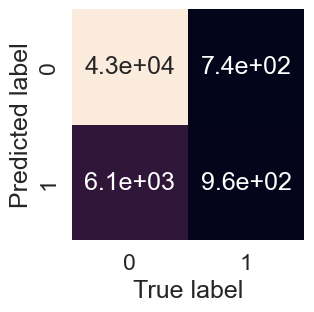

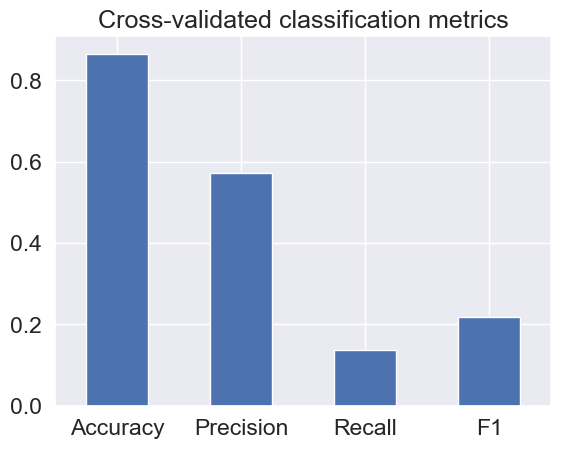

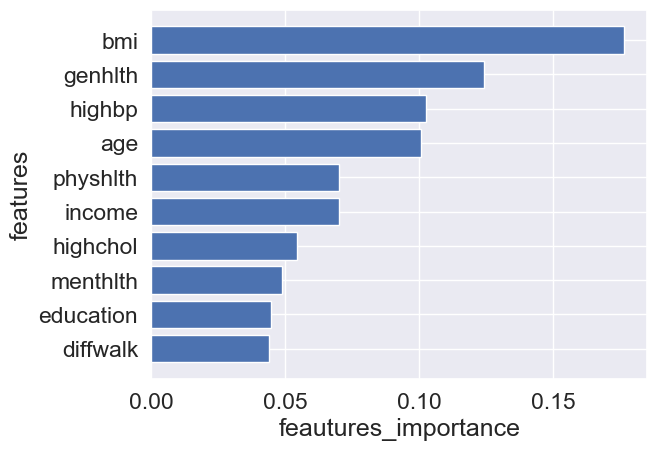

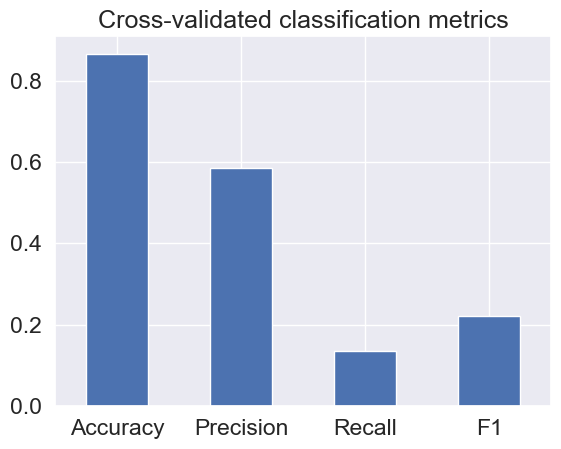

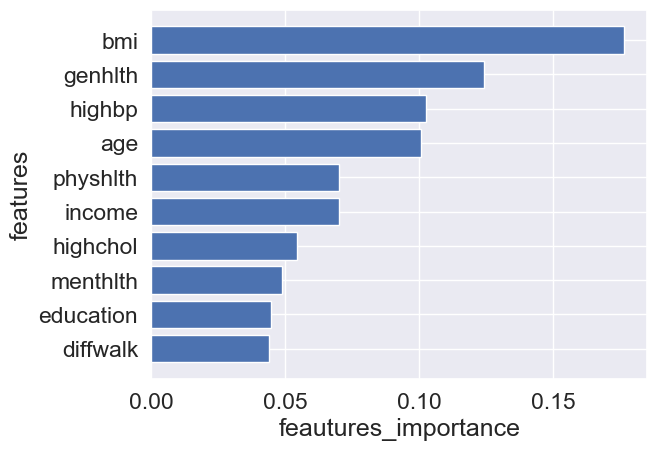

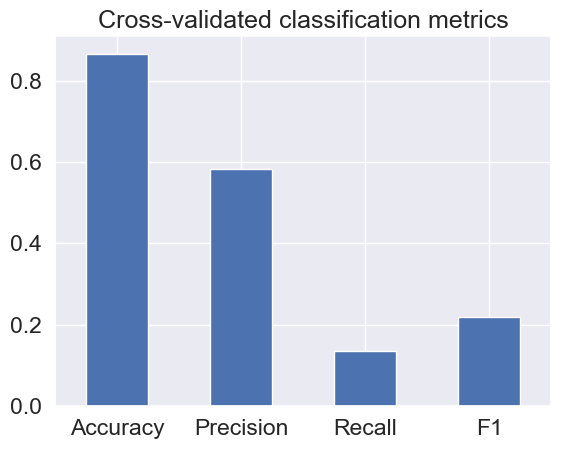

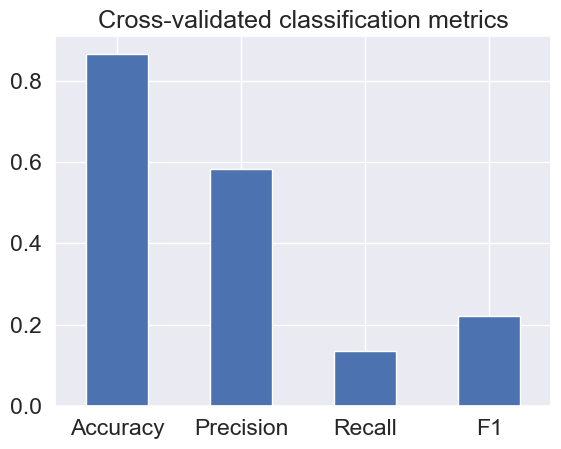

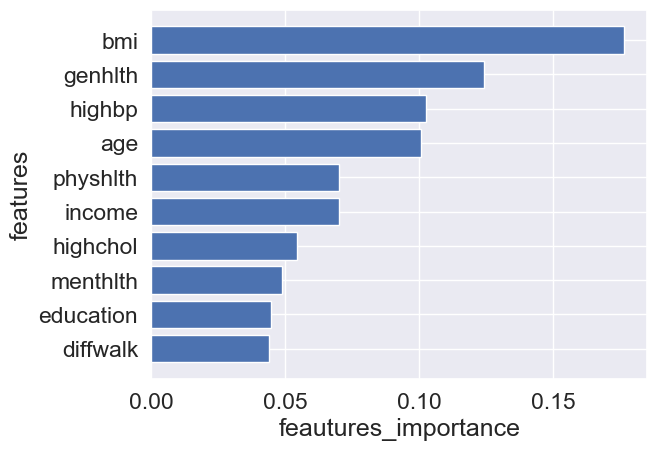

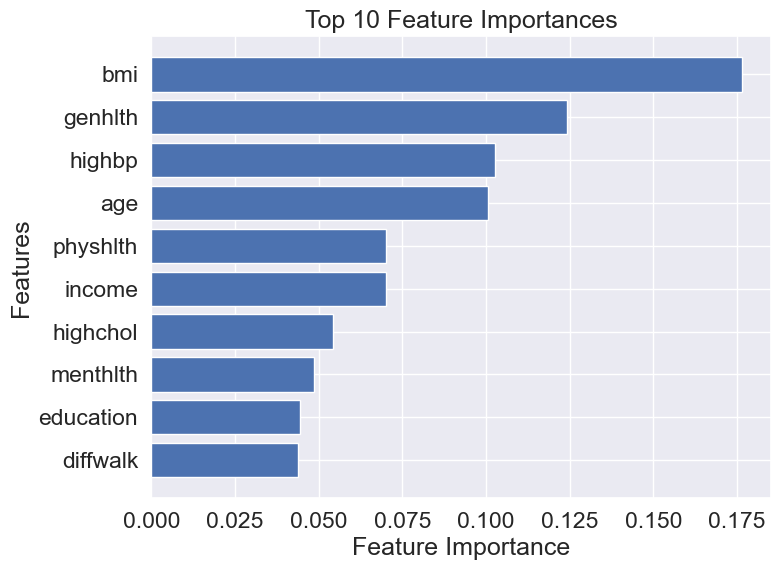

In [76]:
plot_features(X_train.columns, ideal_model.feature_importances_, n=10)